# **One Hot Encoding(OHE)**

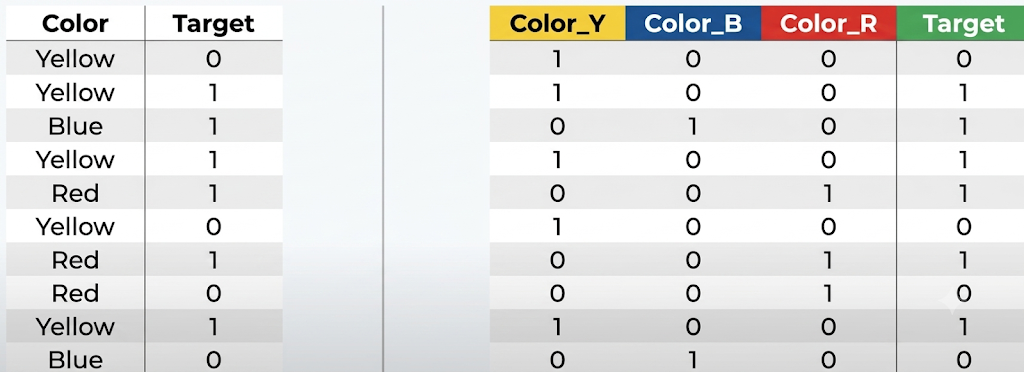

**nominal data:** *categorical data that isnt related to each other(one isnt greater than the other)*

ex: color['yellow', 'blue', 'red']

### One-Hot Encoding & The Multicollinearity Trap

* **Concept:** 1 column gets transformed into $n$ columns ($n$ distinct values).
* **Example:** Above example: 1 column `Color` became 3 columns ($n=3$).

> 💡 **Best Practice:** Use $n-1$ columns to represent the data (Dummy Variable Trap!).

#### The Problem: Multicollinearity
* The sum for all 3 columns = 1.
* This (**multicollinearity**) is problematic for linear ML models (Linear Regression, Logistic Regression).

#### The Solution
To get rid of this ("multicollinearity trap"), we use $n-1$ columns.

**Representation** *(Suppose we removed `Color_Y`)*:
* $[0,0] = 1$ (is Yellow) — *OR logic*
* $[1,0] = 0$
* $[0,1] = 0$

In [59]:
import pandas as pd
df = pd.read_csv('cars.csv')
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


### Handling High Cardinality Categorical Variables

* **The Problem:** It has ~40 such brands. If we use the method above, we will convert 1 column (`brand`) into 40 different columns, which is problematic.
* **The Solution:** We pick the top most frequent brands and make their columns, and make a single column for others (called `'others'`). 

> 💡 **Outcome:** Instead of 40, we get only 10 columns.

In [60]:
df['brand'].value_counts()

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

# 1. OneHotEncoding using Pandas

In [61]:
pd.get_dummies(df, columns=['fuel','owner'] ,dtype=int) #without dtype=int: True/False insted of 0/1

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


# 2. k-1(n-1) OHE

*remember we talked abt n-1 cols instead of n cols? This is it!*

In [62]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=int,drop_first=True) 

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


*We dont use this pandas function for ML coz it doesnt remember the positions of generated cols os we use **sklearn**'s function called **OneHotEncoder***

# 3. OHE Using Sklearn

In [63]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop(columns=['selling_price']),
                                                df['selling_price'],
                                                test_size=0.2,
                                                random_state=0)

In [64]:
X_train.head()

,brand,km_driven,fuel,owner
3042,Hyundai,60000,LPG,First Owner
1520,Tata,150000,Diesel,Third Owner
2611,Hyundai,110000,Diesel,Second Owner
3544,Mahindra,28000,Diesel,Second Owner
4138,Maruti,15000,Petrol,First Owner


In [65]:
X_test.head()

,brand,km_driven,fuel,owner
3558,Hyundai,40000,Diesel,First Owner
233,Mahindra,70000,Diesel,First Owner
7952,Maruti,5000,Petrol,First Owner
572,Maruti,120000,Petrol,Third Owner
6960,Lexus,20000,Petrol,First Owner


In [66]:
from sklearn.preprocessing import OneHotEncoder

In [81]:
ohe = OneHotEncoder(drop='first', dtype=int)  #Here drop true will drop 1 col (n-1)

*small problem: today we r gonna have to apply OHE saperately on col required then integrate it back to original df but later we can do it in a single line after learning **column transformer***

In [82]:
X_train_new = ohe.fit_transform(X_train[['fuel','owner']])
X_test_new = ohe.transform(X_test[['fuel','owner']])

In [83]:
X_train_new

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8735 stored elements and shape (6502, 7)>

In [84]:
# since it gives sparse row we have to convert it to array
# Alternate option: use 'sparse=False' here: ohe = OneHotEncoder(drop='first') (better)

X_train_new = ohe.fit_transform(X_train[['fuel','owner']]).toarray()
X_test_new = ohe.transform(X_test[['fuel','owner']]).toarray

In [85]:
X_train_new

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 1],
       [1, 0, 0, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]], shape=(6502, 7))

**Now we have to attach thise array cols to remaining cols for final df**

## 1

In [86]:
X_train[['brand','km_driven']]

,brand,km_driven
3042,Hyundai,60000
1520,Tata,150000
2611,Hyundai,110000
3544,Mahindra,28000
4138,Maruti,15000
...,...,...
4931,Tata,70000
3264,Ford,100000
1653,Hyundai,90000
2607,Volkswagen,90000


## 2

In [87]:
X_train[['brand','km_driven']].values

array([['Hyundai', 60000],
       ['Tata', 150000],
       ['Hyundai', 110000],
       ...,
       ['Hyundai', 90000],
       ['Volkswagen', 90000],
       ['Hyundai', 110000]], shape=(6502, 2), dtype=object)

## 3

In [88]:
import numpy as np
np.hstack((X_train[['brand','km_driven']].values, X_train_new)) #here 'hstack' has horizontally stacked both groups

array([['Hyundai', 60000, 0, ..., 0, 0, 0],
       ['Tata', 150000, 1, ..., 0, 0, 1],
       ['Hyundai', 110000, 1, ..., 1, 0, 0],
       ...,
       ['Hyundai', 90000, 0, ..., 1, 0, 0],
       ['Volkswagen', 90000, 1, ..., 0, 0, 0],
       ['Hyundai', 110000, 0, ..., 0, 0, 0]],
      shape=(6502, 9), dtype=object)

### **With ohe = OneHotEncoder() .shape: (6502, 11)**

In [89]:
np.hstack((X_train[['brand','km_driven']].values, X_train_new)).shape 

(6502, 9)

# 4. OHE with top categories

In [93]:
df['brand'].value_counts()

brand
Maruti           2448
Hyundai          1415
Mahindra          772
Tata              734
Toyota            488
Honda             467
Ford              397
Chevrolet         230
Renault           228
Volkswagen        186
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               40
Lexus              34
Jeep               31
Mitsubishi         14
Land                6
Force               6
Isuzu               5
Kia                 4
Ambassador          4
MG                  3
Daewoo              3
Ashok               1
Opel                1
Peugeot             1
Name: count, dtype: int64

### **Threshold:** 100, if count > 100 = brand gets indivisual col, else: 'others'

In [95]:
count = df['brand'].value_counts()
threshold = 100

In [97]:
df['brand'].nunique

<bound method IndexOpsMixin.nunique of 0        Maruti
1         Skoda
2         Honda
3       Hyundai
4        Maruti
         ...   
8123    Hyundai
8124    Hyundai
8125     Maruti
8126       Tata
8127       Tata
Name: brand, Length: 8128, dtype: str>

In [102]:
rare = count[count <= 100].index

In [103]:
rare

Index(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Kia',
       'Ambassador', 'MG', 'Daewoo', 'Ashok', 'Opel', 'Peugeot'],
      dtype='str', name='brand')

In [107]:
df = pd.get_dummies(df['brand'].replace(rare, 'Others'), dtype=int)

In [113]:
df.sample(10)

,BMW,Chevrolet,Ford,Honda,Hyundai,Mahindra,Maruti,Others,Renault,Skoda,Tata,Toyota,Volkswagen
2507,0,0,0,0,0,0,1,0,0,0,0,0,0
1199,0,0,0,0,0,0,1,0,0,0,0,0,0
7340,0,0,0,0,0,0,0,1,0,0,0,0,0
6514,0,0,0,0,0,0,1,0,0,0,0,0,0
702,0,0,0,0,0,0,1,0,0,0,0,0,0
7515,0,0,0,0,0,0,1,0,0,0,0,0,0
1983,0,0,0,0,0,0,1,0,0,0,0,0,0
3826,0,0,0,0,0,0,1,0,0,0,0,0,0
5217,0,0,0,0,0,0,0,0,0,0,1,0,0
3268,0,0,0,0,1,0,0,0,0,0,0,0,0
